In [1]:
import sys

assert sys.version_info >= (3,10)

In [2]:
from packaging.version import Version
import torch

assert Version(torch.__version__) >= Version("2.6.0")

This chapter can be very slow without a hardware accelerator, so if we can find one, let's use it:

In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device  = "mps"
else:
    device = 'cpu'

device

'cuda'

Let's issue a warning if ther's no hardware accelerator availabel:

In [4]:
if device == "cpu":
    print("Neural nets can be very slow without a hardware accelerator.")
    

As we did in earlier chapters, let's define the default font sizes to make the figures prettier:

In [5]:
import matplotlib.pyplot as plt

plt.rc("font", size=14)
plt.rc("axes", labelsize=14, titlesize=14)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)

We will also be using the same train() and evaluate_tm() functions as in previous chapters, but with a couple tweaks to the train() function:

In [6]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch  =  X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            if isinstance(y_pred, tuple):
                y_pred  = y_pred.output
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=2, factor=0.5, epoch_callback=None):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=patience, factor=factor)
    history = {"train_losses": [],
               "train_metrics": [],
               "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        if epoch_callback is not None:
            epoch_callback(model, epoch)
        for index, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
            train_metric = metric.compute().item()
            print(f"\rBatch {index + 1}/{len(train_loader)}", end="")
            print(f", loss={total_loss/(index + 1):.4f}", end="")
            print(f", {train_metric=:.3f}", end="")

        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(train_metric)
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        scheduler.step(val_metric)
        print(f"\rEpoch {epoch + 1}/{n_epochs},                      "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.3}, "
              f"valid metric: {history['valid_metrics'][-1]:.3}")
    return history

/home/ziaur/ziazh/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Performing PCA with a Undercomplete Linear Autoencoder


Let's build the Autoencoder...

In [7]:
import torch
import torch.nn as nn 

torch.manual_seed(42)
encoder = nn.Linear(3,2)
decoder = nn.Linear(2,3)
autoencoder = nn.Sequential(encoder, decoder).to(device)

Now let's generate the same 3D dataset as we used in chapter7:

In [8]:
import numpy as np
from scipy.spatial.transform import Rotation

def generate_data(m, seed=42):
    X = np.zeros((m,3))
    rng = np.random.default_rng(seed)
    angles = (rng.random(m) ** 3 + 0.5) * 2 * np.pi
    X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5
    X += 0.28 * rng.standard_normal((m, 3))
    X = Rotation.from_rotvec([np.pi / 29, -np.pi / 20, np.pi / 4]).apply(X)
    X += [0.2, 0, 0.2]
    # print( X[:, 0])
    return torch.from_numpy(X.astype(np.float32))

In [9]:
generate_data(4)

tensor([[ 0.8339, -0.0442,  0.2941],
        [-0.2548, -0.8045, -0.2166],
        [ 0.4185,  1.0476,  0.4067],
        [ 1.0219,  0.4200,  0.1054]])

In [10]:
from torch.utils.data import DataLoader, TensorDataset

X_train = generate_data(60, seed=42)
train_set = TensorDataset(X_train, X_train)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

In [11]:
X_valid = generate_data(500, seed=42)
valid_set = TensorDataset(X_valid, X_valid)
valid_loader = DataLoader(valid_set, batch_size=32)


In [12]:
import torchmetrics

torch.manual_seed(42)
optimizer = torch.optim.NAdam(autoencoder.parameters(), lr=0.2)
mse = nn.MSELoss()
rmse =torchmetrics.MeanSquaredError(squared=False).to(device)
# history = train(autoencoder, optimizer, mse, rmse, train_loader, valid_loader, n_epochs=20)

In [13]:
codings = encoder(X_train.to(device))

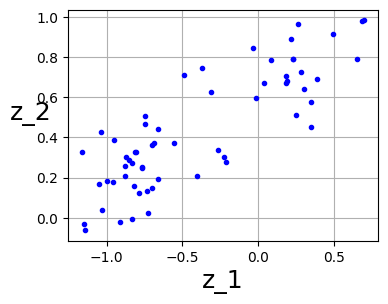

In [14]:
fig = plt.figure(figsize=(4,3))
codings_np = codings.cpu().detach().numpy()
plt.plot(codings_np[:, 0], codings_np[:, 1], "b.")
plt.xlabel("z_1", fontsize=18)
plt.ylabel("z_2", fontsize=18, rotation=0)
plt.grid(True)

plt.show()

Stacked Autoencoders

Implementing a Stacked Autoencoder Using Pytorch

Let's build and train a stacked Autoencoder with 3 hidden layers and 1 output layer(i.e., 2 stacked Autoencoders)

In [15]:
torch.manual_seed(42)

stacked_encoder = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
    nn.Linear(128, 32), nn.ReLU(),
)
stacked_decoder = nn.Sequential(
    nn.Linear(32, 128), nn.ReLU(),
    nn.Linear(128, 1*28*28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1,28,28)))

stacked_ae = nn.Sequential(stacked_encoder, stacked_decoder).to(device)

Let's load the fashion MNIST dataset, and split it into a trainig set, a validation set, and test set:


In [16]:
import torchvision
import torchvision.transforms.v2 as T 

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor
)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000]
)

In [17]:
from torch.utils.data import Dataset

class AutoencoderDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        x, _ = self.base_dataset[idx]
        return x, x

train_loader = DataLoader(AutoencoderDataset(train_data), batch_size=32, shuffle=True)
valid_loader = DataLoader(AutoencoderDataset(valid_data), batch_size=32,)
test_loader = DataLoader(AutoencoderDataset(test_data), batch_size=32)
        

In [18]:
optimizer = torch.optim.NAdam(stacked_ae.parameters(), lr=0.01)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
# history = train(stacked_ae, optimizer, mse, rmse, train_loader, valid_loader, n_epochs=10)

Visualizing the Reconstructions

This function processes a few validation images through the autoencoder and displays the original images and their reconstructions:

In [19]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0).cpu(), cmap="binary")
    plt.axis("off")

def plot_reconstructions(model, images, n_images=5):
    images  = images[:n_images]
    with torch.no_grad():
        y_pred = model(images.to(device))
    if isinstance(y_pred, tuple):
        y_pred = y_pred.output
    fig = plt.figure(figsize=(len(images) * 1.5, 3))
    for idx in range(len(images)):
        plt.subplot(2, len(images), 1 + idx)
        plot_image(images[idx])
        plt.subplot(2, len(images), 1 + len(images) + idx)
        plot_image(y_pred[idx])

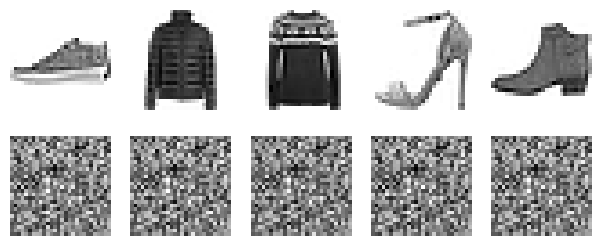

In [20]:
X_valid = torch.stack([x for x, _ in valid_data])
plot_reconstructions(stacked_ae, X_valid)

plt.show()

The reconstructions look fuzzy, but remember that the images were compressed down to just 32 numbers, instead of 784

Using AutoEncoders for Anomaly Detection

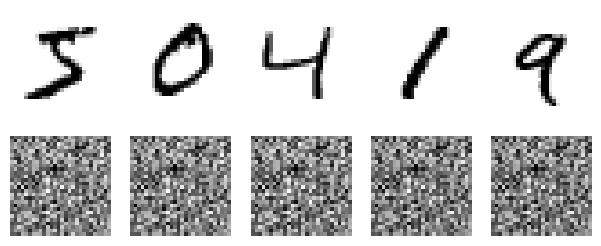

In [21]:
torch.manual_seed(42)
mnist_data = torchvision.datasets.MNIST(
    root="datasets", train=True, download=True, transform=toTensor)
mnist_images = torch.stack([mnist_data[i][0] for i in range(X_valid.size(0))])
plot_reconstructions(stacked_ae, images=mnist_images)
plt.show()

In [22]:
images = mnist_images.to(device)
with torch.no_grad():
    y_pred = stacked_ae(images)
    recon_loss  = torch.nn.functional.mse_loss(y_pred, images)

recon_loss

tensor(0.2313, device='cuda:0')

if we compare the reconstruction losses for all Fashion MNIST images and all MNIST images, we can see that the latter are much higher on averag:


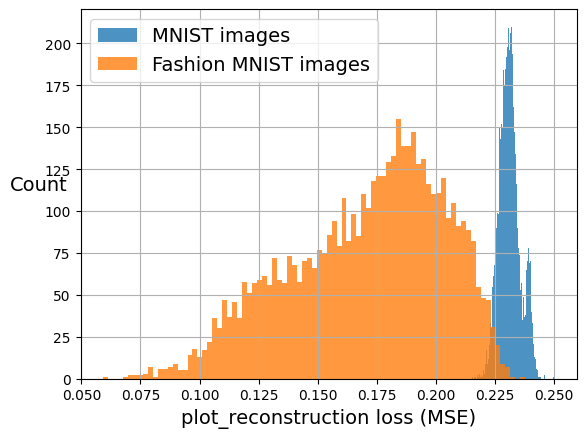

In [23]:
import torch.nn.functional as F 

def compute_reconstruction_losses(X, device):
    X = X.to(device)
    with torch.no_grad():
        y_pred = stacked_ae(X)
        return F.mse_loss(y_pred, X, reduction="none").view(X.size(0), -1).mean(dim=1).cpu()

recon_losses_mnist = compute_reconstruction_losses(mnist_images, device)
recon_losses_fashion_mnist = compute_reconstruction_losses(X_valid, device)

plt.hist(recon_losses_mnist, bins=85, alpha=0.8, label="MNIST images")
plt.hist(recon_losses_fashion_mnist, bins=85, alpha=0.8, label='Fashion MNIST images')
plt.xlabel("plot_reconstruction loss (MSE)")
plt.ylabel("Count", rotation=0)
plt.legend()
plt.grid()

plt.show()

Visualizing the Fashion MNIST Dataset

In [24]:
from sklearn.manifold import TSNE

with torch.no_grad():
    X_valid_compressed = stacked_encoder(X_valid.to(device))

tsne = TSNE(init="pca", learning_rate="auto", random_state=42)
X_valid_2D = tsne.fit_transform(X_valid_compressed.cpu())


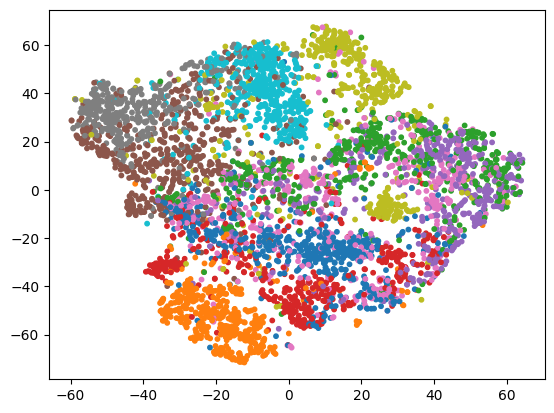

In [25]:
y_valid = torch.tensor([y for _ , y in valid_data])
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap="tab10")
plt.show()

Let's make this diagram prettier(adapted from this scikit-learn example):

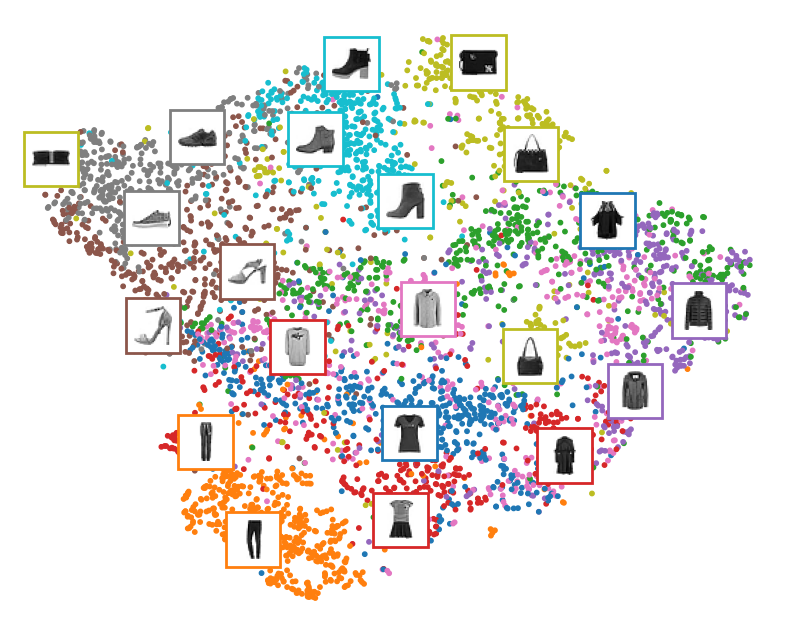

In [26]:
import matplotlib as mpl

plt.figure(figsize=(10, 8))
cmap = plt.cm.tab10
Z = X_valid_2D
Z = (Z - Z.min()) / (Z.max() - Z.min())
plt.scatter(Z[:, 0], Z[:, 1], c=y_valid, s=10, cmap=cmap)
image_positions = np.array([[1., 1.]])
for index, position in enumerate(Z):
    dist = ((position - image_positions) ** 2). sum(axis=1)
    if dist.min() > .02:
        image_positions = np.r_[image_positions, [position]]
        imagebox = mpl.offsetbox.AnnotationBbox(
            mpl.offsetbox.OffsetImage(X_valid[index].squeeze(dim=0),
                                      cmap="binary"),
            position, bboxprops={"edgecolor": cmap(y_valid[index]), "lw": 2})
        plt.gca().add_artist(imagebox)

plt.axis("off")

plt.show()

Tying weights

It is common to tie the weights of the encoder and the decoder, by simply using the transpose of the encoder's weights as the decoder weights. For this, we can use a custor module.

In [27]:
import torch.nn.functional as F 

class TiedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Linear(1 * 28 * 28, 128)
        self.enc2 = nn.Linear(128, 32)
        self.dec1_bias = nn.Parameter(torch.zeros(128))
        self.dec2_bias = nn.Parameter(torch.zeros(1 * 28 * 28))

    def encode(self, X):
        Z = X.view(-1, 1 * 28 * 28)
        Z = F.relu(self.enc1(Z))
        return F.relu(self.enc2(Z))

    def decode(self, X):
        Z = F.relu(F.linear(X, self.enc2.weight.t(), self.dec1_bias))
        Z = F.sigmoid(F.linear(Z, self.enc1.weight.t(), self.dec2_bias))
        return Z.view(-1, 1, 28, 28)

    def forward(self, X):
        return self.decode(self.encode(X))

In [28]:
tied_ae = TiedAutoencoder().to(device)
optimizer = torch.optim.NAdam(tied_ae.parameters(), lr=0.01)
# history = train(tied_ae, optimizer, mse, rmse, train_loader, valid_loader,n_epochs=10)

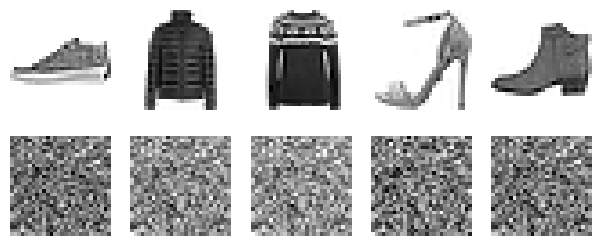

In [29]:
plot_reconstructions(tied_ae, X_valid)
plt.show()

Convolutional Autoencoders

Let's build a stacked Autoencoder with 3 hiddn layers and 1 output layer(i.e., 2 stacked autoencoders)

In [30]:
torch.manual_seed(42)

conv_encoder = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding="same"),nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(16, 32, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(32, 64, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(64, 32, kernel_size=3, padding="same"), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1,1)), nn.Flatten()
)

conv_decoder = nn.Sequential(
    nn.Linear(32, 16 * 3 * 3),
    nn.Unflatten(dim=1, unflattened_size=(16, 3, 3)),
    nn.ConvTranspose2d(16, 32, kernel_size=3, stride=2), nn.ReLU(),
    nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1,
                       output_padding=1), nn.ReLU(),
    nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1,
                       output_padding=1), nn.Sigmoid()
)

conv_ae = nn.Sequential(conv_encoder, conv_decoder).to(device)

In [31]:
optimizer = torch.optim.NAdam(conv_ae.parameters(), lr=0.005)
# history = train(conv_ae, optimizer, mse, rmse, train_loader, valid_loader,
                # n_epochs=10)

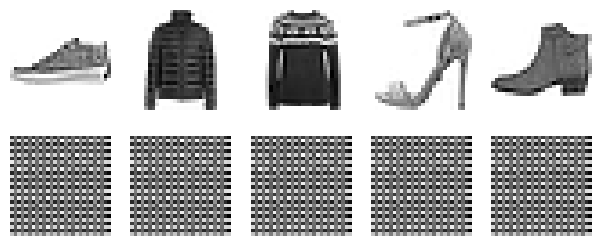

In [32]:
plot_reconstructions(conv_ae, X_valid)
plt.show()

Extra Material - Recurrent Autoencoders

Let's treat each Fashion MNIST image as a sequence of 28 vectors, each with 28 dimensions:

In [33]:
class RecurrentAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder_lstm = nn.LSTM(input_size=28, hidden_size=128, num_layers=2, batch_first=True)
        self.encoder_proj = nn.Linear(128, 32)
        self.decoder_lstm = nn.LSTM(input_size=32, hidden_size=128,
                                    batch_first=True)
        self.decoder_proj = nn.Linear(128, 28)

    def encode(self, X):
        Z = X.squeeze(dim=1)
        _, (h_n, _) = self.encoder_lstm(Z)
        Z = h_n[-1]
        return self.encoder_proj(Z)

    def decode(self, X):
        Z = X.unsqueeze(dim=1).repeat(1, 28, 1)
        Z, _ = self.decoder_lstm(Z)
        return F.sigmoid(self.decoder_proj(Z).unsqueeze(dim=1))

    def forward(self, X):
        return self.decode(self.encode(X))

torch.manual_seed(42)
recurrent_ae = RecurrentAutoencoder().to(device)



In [34]:
optimizer = torch.optim.NAdam(recurrent_ae.parameters(), lr=1e-3)
# history = train(recurrent_ae, optimizer, mse, rmse, train_loader, valid_loader,
#                 n_epochs=10)

Denoising Autoencoders

Using dropout:

In [35]:
torch.manual_seed(42)

dropout_encoder = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(0.5),
    nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
    nn.Linear(128,128), nn.ReLU(),
    )
dropout_decoder = nn.Sequential(
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 1 * 28  * 28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
    )
dropout_ae = nn.Sequential(dropout_encoder, dropout_decoder).to(device)

In [36]:
optimizer = torch.optim.NAdam(dropout_ae.parameters(), lr=0.01)
# history = train(dropout_ae, optimizer, mse, rmse, train_loader, valid_loader,
#                 n_epochs=10)

Instead of using Dropout, we can add Gaussian noise:


In [37]:
class GaussianNoise(nn.Module):
    def __init__(self, std):
        super().__init__()
        self.std =std

    def forward(self, X):
        if self.training:
            noise = torch.randn_like(X) * self.std
            return X + noise

        return X
    

In [38]:
torch.manual_seed(42)
noise_encoder = nn.Sequential(
    nn.Flatten(),
    GaussianNoise(0.5),
    nn.Linear(1 * 28 *28, 128), nn.ReLU(),
    nn.Linear(128,128), nn.ReLU(),
)
noise_decoder = nn.Sequential(
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
)
noise_ae = nn.Sequential(noise_encoder, noise_decoder).to(device)

Sparse Autoencoder

Let's use the sigmoid activation function in the coding layer. Let's also add l1 regularization to it: to do this, we make the module return both the reconstruction and the encodings(i.e., the output of the encoder), so the regularization loss can be computed based on the encodings

In [39]:
from collections import namedtuple

AEOutput = namedtuple("AEOutput", ["output", "codings"])

class  SparseAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1 * 28 *28, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.Sigmoid(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
            nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
        )
    def forward(self, X):
        codings = self.encoder(X)
        output = self.decoder(codings)
        return AEOutput(output, codings)

In [40]:
def mse_plus_sparsity_loss(y_pred, y_target, target_sparsity=0.1,
                           kl_weight=1e-3, eps=1e-8):
    p = torch.tensor(target_sparsity, device=y_pred.codings.device)
    q = torch.clamp(y_pred.codings.mean(dim=0), eps, 1-eps)
    kl_div = p * torch.log(p/q) + (1-p) * torch.log((1-p) /(1-q))
    return mse(y_pred.output, y_target) + kl_weight * kl_div.sum()

In [41]:
torch.manual_seed(42)
sparse_ae = SparseAutoencoder().to(device)
optimizer = torch.optim.NAdam(sparse_ae.parameters(), lr=0.002)
# history = train(sparse_ae, optimizer, mse_plus_sparsity_loss, rmse,
#                 train_loader, valid_loader, n_epochs=10)

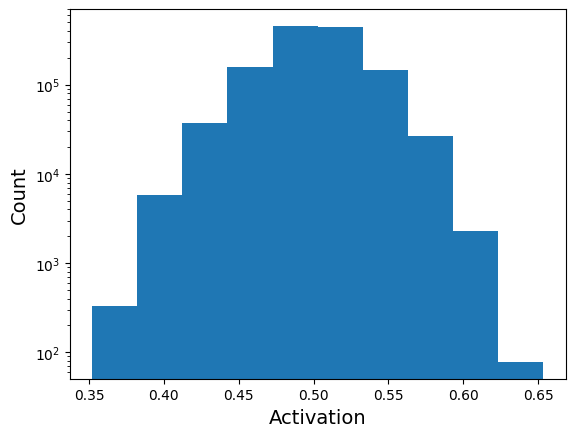

In [42]:
with torch.no_grad():
    y_pred = sparse_ae(X_valid.to(device))

encs = y_pred.codings.flatten().detach().cpu()
plt.hist(encs, log=True)
plt.xlabel("Activation")
plt.ylabel("Count")
plt.show()

torch.Size([5000, 256])
4500


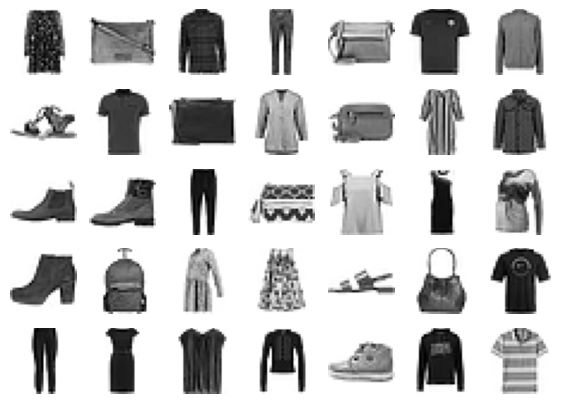

In [43]:
def plot_multiple_images(images, n_cols=None):
    n_cols = n_cols or len(images)
    n_rows = (len(images) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows))
    for index, image in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        plot_image(image)
print(y_pred.codings.shape)
dim = 255
codings = y_pred.codings[:, dim].cpu()
threshold = np.percentile(codings, 10)
selected_images = X_valid[codings > threshold]
print(len(selected_images))
plot_multiple_images(selected_images[1000:1035], 7)
plt.show()

Variational Autoencoders

In [44]:
VAEOutput = namedtuple("VAEOutput",
                       ["output", "codings_mean","codings_logvar"])

class VAE(nn.Module):
    def __init__(self, codings_dim=32):
        super().__init__()
        self.codings_dim = codings_dim
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1 * 28 *28, 128), nn.ReLU(),
            nn.Linear(128, 2 * codings_dim))
        self.decoder = nn.Sequential(
            nn.Linear(codings_dim, 128), nn.ReLU(),
            nn.Linear(128, 1 * 28 *28), nn.Sigmoid(),
            nn.Unflatten(dim=1, unflattened_size=(1, 28, 28)))
        
    def encode(self, X):
        return self.encoder(X).chunk(2, dim=1)

    def sample_codings(self, codings_mean, codings_logvar):
        codings_std  = torch.exp(0.5 * codings_logvar)
        noise = torch.randn_like(codings_std)
        return codings_mean + noise * codings_std
    def decode(self, Z):
        return self.decoder(Z)
    
    def forward(self, X):        
        codings_mean, codings_logvar = self.encode(X)
        codings = self.sample_codings(codings_mean, codings_logvar)
        output = self.decode(codings)
        return VAEOutput(output, codings_mean, codings_logvar)                    

In [45]:
def vae_loss(y_pred, y_target, kl_weight=1.0):
    output, mean, logvar = y_pred
    kl_div = -0.5 * torch.sum(1 + logvar -logvar.exp() - mean.square(), dim=-1)
    return F.mse_loss(output, y_target) + kl_weight * kl_div.mean() / 784

In [46]:
torch.manual_seed(42)
vae = VAE().to(device)
optimizer = torch.optim.NAdam(vae.parameters(), lr=1e-3)
# history = train(vae, optimizer, vae_loss, rmse, train_loader, valid_loader,
#                 n_epochs=10)

In [47]:
vae.codings_dim

32

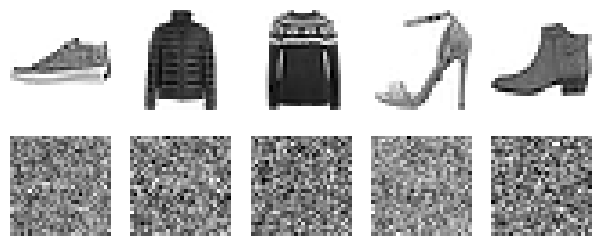

In [48]:
plot_reconstructions(vae, X_valid)
plt.show()

Generate Fashion Images

Let's generate a few random codings and decode them:

In [49]:
torch.manual_seed(42)

vae.eval()
codings = torch.randn(3 * 7, vae.codings_dim, device=device)
with torch.no_grad():
    images = vae.decode(codings)

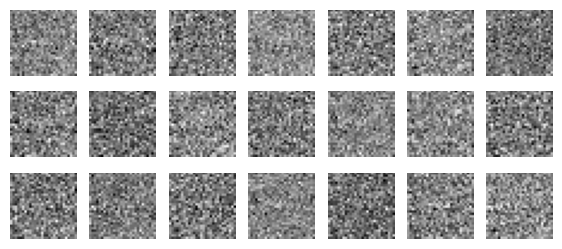

In [50]:
plot_multiple_images(images, 7)
plt.show()

In [51]:
torch.manual_seed(111)

codings = torch.randn(2, vae.codings_dim)
n_images  = 7
weights = torch.linspace(0, 1, n_images).view(n_images, 1)
codings = torch.lerp(codings[0], codings[1], weights)
with torch.no_grad():
    images = vae.decode(codings.to(device))
    

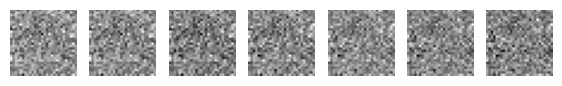

In [52]:
plot_multiple_images(images)

plt.show()

In [53]:
def gumbel_softmax(logits, tau=1, hard=False, dim=-1):
    if device != "mps":
        return F.gumbel_softmax(logits, tau, hard, dim)
    gumbels = (
        -torch.empty_like(logits, memory_format=torch.legacy_contiguous_format)
        .exponential_()
        .log()
    )  # ~Gumbel(0,1)
    gumbels = torch.clamp(gumbels, -30, 30)  # <<<<<<<<<<<<<<<<<<<<< ADDED
    gumbels = (logits + gumbels) / tau  # ~Gumbel(logits,tau)
    y_soft = gumbels.softmax(dim)

    if hard:
        # Straight through.
        index = y_soft.max(dim, keepdim=True)[1]
        y_hard = torch.zeros_like(
            logits, memory_format=torch.legacy_contiguous_format
        ).scatter_(dim, index, 1.0)
        ret = y_hard - y_soft.detach() + y_soft
    else:
        # Reparametrization trick.
        ret = y_soft
    return ret

Discrete VAE

In [54]:
DiscreteVAEOutput  = namedtuple("DiscreteVAEOutput",
                                ["output", "logits","codings_prob"])

class DiscreteVAE(nn.Module):
    def __init__(self, coding_length=32, n_codes=16, temperature=1.0):
        super().__init__()
        self.coding_length = coding_length
        self.n_codes = n_codes
        self.temperature = temperature
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1 * 28 * 28, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, coding_length * n_codes),
            nn.Unflatten(dim=1, unflattened_size=(coding_length, n_codes)))
        self.decoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(coding_length * n_codes, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 1 *28 *  28), nn.Sigmoid(),
            nn.Unflatten(dim=1, unflattened_size=(1,28,28)))

    def forward(self, X):
        logits  = self.encoder(X)
        codings_prob = gumbel_softmax(logits, tau=self.temperature, hard=True)
        output = self.decoder(codings_prob)
        return DiscreteVAEOutput(output, logits, codings_prob)

In [55]:
def d_vae_loss(y_pred, y_target, kl_weight=1.0):
    output, logits, _ = y_pred
    codings_prob = F.softmax(logits, -1)
    k = logits.new_tensor(logits.size(-1))  # same device and dtype as logits
    kl_div = (codings_prob * (codings_prob.log() + k.log())).sum(dim=(1, 2))
    return F.mse_loss(output, y_target) + kl_weight * kl_div.mean() / 784

In [56]:
n_epochs = 2
def annealing(model, epoch):
    model.temperature = 1 - 0.9 * epoch / n_epochs

torch.manual_seed(42)
d_vae = DiscreteVAE().to(device)
optimizer = torch.optim.NAdam(d_vae.parameters(), lr=0.001)
# history = train(d_vae, optimizer, d_vae_loss, rmse, train_loader, valid_loader,
#                 n_epochs=n_epochs, epoch_callback=annealing)

In [57]:
torch.manual_seed(42)  # extra code – ensures reproducibility
n_images = 3 * 7
codings = torch.randint(0, d_vae.n_codes,  # from 0 to k – 1
                        (n_images, d_vae.coding_length), device=device)
codings_prob = F.one_hot(codings, num_classes=d_vae.n_codes).float()
# print(codings_prob.shape)
with torch.no_grad():
    images = d_vae.decoder(codings_prob)

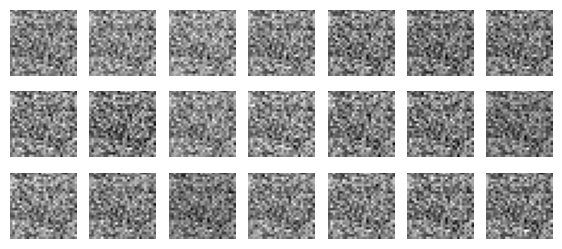

In [58]:
plot_multiple_images(images, 7)
plt.show()

Generative Adversarial Networks

In [59]:
torch.manual_seed(42)

codings_dim = 32
generator = nn.Sequential(
    nn.Linear(codings_dim, 128), nn.ReLU(),
    nn.Linear(128, 256), nn.ReLU(),
    nn.Linear(256, 1 * 28 * 28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1,28,28))).to(device)
discriminator = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 *28, 256), nn.ReLU(),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, 1), nn.Sigmoid()
).to(device)

In [60]:
def train_gan(generator, discriminator, train_loader, codings_dim, n_epochs,
              g_lr=1e-3, d_lr=5e-4):
    criterion = nn.BCELoss()
    generator_opt = torch.optim.NAdam(generator.parameters(), lr=g_lr)
    discriminator_opt = torch.optim.NAdam(discriminator.parameters(), lr=d_lr)
    for epoch in range(n_epochs):
        print(f"Epoch {epoch + 1} /{n_epochs}", end="")
        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            pred_real = discriminator(real_images)
            batch_size = real_images.size(0)
            ones = torch.ones(batch_size, 1 , device=device)
            real_loss = criterion(pred_real, ones)
            codings = torch.randn(batch_size, codings_dim, device=device)
            fake_images = generator(codings).detach()
            pred_fake = discriminator(fake_images)
            zeros = torch.zeros(batch_size, 1, device=device)
            fake_loss  = criterion(pred_fake, zeros)
            discriminator_loss = real_loss + fake_loss
            discriminator_opt.zero_grad()
            discriminator_loss.backward()
            discriminator_opt.step()

            codings = torch.randn(batch_size, codings_dim, device=device)
            fake_images = generator(codings)
            for p in discriminator.parameters():
                p.requires_grad = False
            pred_fake = discriminator(fake_images)
            generator_loss = criterion(pred_fake, ones)
            generator_opt.zero_grad()
            generator_loss.backward()
            generator_opt.step()
            for p in discriminator.parameters():
                p.requires_grad = True
        print(f" | discriminator loss: {discriminator_loss.item():.4f}", end="")
        print(f" | generator loss: {generator_loss.item():.4f}")
        if epoch % 10 == 0 or epoch == n_epochs - 1:
            plot_multiple_images(fake_images.detach(), 8)
            plt.show()



In [61]:
torch.manual_seed(41)  # trying another seed often fixes the issue 😅
# train_gan(generator, discriminator, train_loader, codings_dim,n_epochs=20)

In [62]:
torch.manual_seed(42)
n_images = 3 * 7
generator.eval()
codings = torch.randn(n_images, codings_dim, device=device)
with torch.no_grad():
    generated_images = generator(codings)

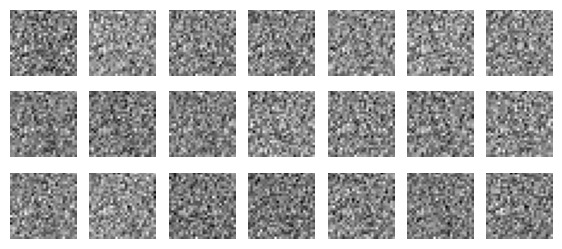

In [63]:
plot_multiple_images(generated_images, 7)

plt.show()

Deep Convolutional GAN

In [66]:
torch.manual_seed(42)

dc_codings_dim=100

dc_generator = nn.Sequential(
    nn.Linear(dc_codings_dim, 128 * 7 * 7),
    nn.Unflatten(dim=1, unflattened_size=(128, 7,7)),
    nn.BatchNorm2d(128),
    nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1,
                       output_padding=1), nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.ConvTranspose2d(64, 1, kernel_size=3, stride=2, padding=1,
                                          output_padding=1), nn.ReLU()).to(device)
dc_discriminator = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2), nn.ReLU(),
    nn.Dropout(0.4),
    nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2), nn.ReLU(),
    nn.Dropout(0.4),
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 1), nn.Sigmoid()
).to(device)


Epoch 1 /20 | discriminator loss: 0.8995 | generator loss: 1.3743


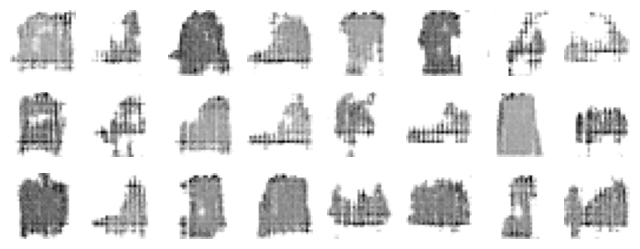

Epoch 2 /20 | discriminator loss: 1.2429 | generator loss: 0.9591
Epoch 3 /20 | discriminator loss: 0.9401 | generator loss: 1.2936
Epoch 4 /20 | discriminator loss: 1.0226 | generator loss: 1.3810
Epoch 5 /20 | discriminator loss: 0.8984 | generator loss: 1.2706
Epoch 6 /20 | discriminator loss: 0.5095 | generator loss: 1.3887
Epoch 7 /20 | discriminator loss: 0.7628 | generator loss: 1.4617
Epoch 8 /20 | discriminator loss: 0.7889 | generator loss: 1.8319
Epoch 9 /20 | discriminator loss: 0.6922 | generator loss: 1.2653
Epoch 10 /20 | discriminator loss: 0.7660 | generator loss: 2.1079
Epoch 11 /20 | discriminator loss: 0.6414 | generator loss: 1.6717


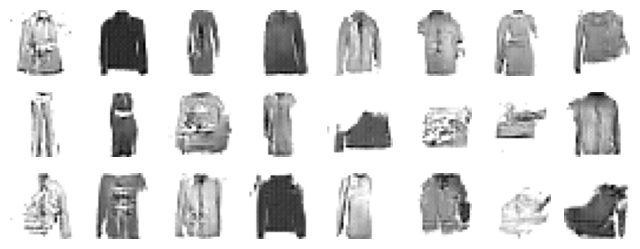

Epoch 12 /20 | discriminator loss: 0.8083 | generator loss: 1.8142
Epoch 13 /20 | discriminator loss: 1.1042 | generator loss: 2.0119
Epoch 14 /20 | discriminator loss: 0.6916 | generator loss: 2.0308
Epoch 15 /20 | discriminator loss: 0.8174 | generator loss: 1.6594
Epoch 16 /20 | discriminator loss: 0.5536 | generator loss: 1.9499
Epoch 17 /20 | discriminator loss: 0.7269 | generator loss: 2.1822
Epoch 18 /20 | discriminator loss: 0.2400 | generator loss: 2.2148
Epoch 19 /20 | discriminator loss: 0.3621 | generator loss: 2.3000
Epoch 20 /20 | discriminator loss: 0.4070 | generator loss: 2.3382


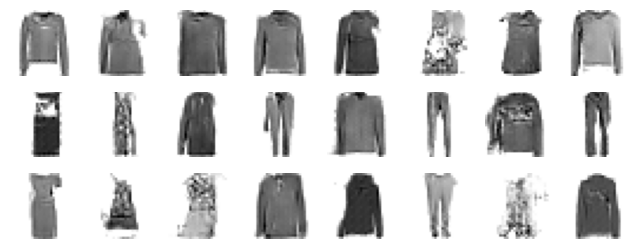

In [67]:
torch.manual_seed(42)
train_gan(dc_generator, dc_discriminator, train_loader, dc_codings_dim,n_epochs=20)

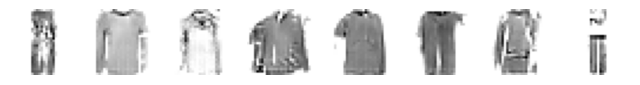

In [68]:
torch.manual_seed(42)
with torch.no_grad():
    codings = torch.randn(8, dc_codings_dim, device=device)
    generated_images = dc_generator(codings)

plot_multiple_images(generated_images, 8)

Diffusion Models

In [73]:
def variance_schedule(T, s=0.008, max_beta=0.999):
    t = torch.linspace(0, T, T + 1)
    f = torch.cos((t / T + s)/ (1 +s) * torch.pi / 2) **2
    alpha_bars = f/ f[0]
    betas = (1 - (f[1:] / f[:-1])).clamp(max=max_beta)
    betas = torch.cat([torch.zeros(1), betas])
    alphas  = 1-betas
    return alphas, betas, alpha_bars

torch.manual_seed(42)
T  = 4000
alphas, betas, alpha_bars = variance_schedule(T)

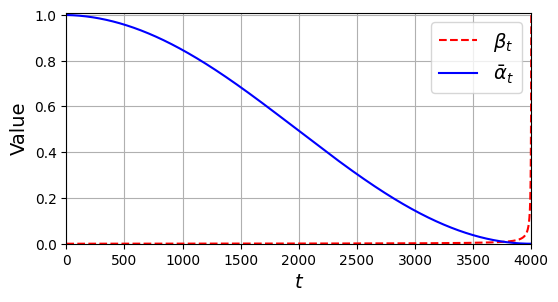

In [74]:
plt.figure(figsize=(6, 3))
plt.plot(betas, "r--", label=r"$\beta_t$")
plt.plot(alpha_bars, "b", label=r"$\bar{\alpha}_t$")
plt.axis([0, T, 0, 1.01])
plt.grid(True)
plt.xlabel("$t$")
plt.ylabel(r"Value")
plt.legend()

plt.show()

In [81]:
def forward_diffusion(x0, t):
    eps = torch.randn_like(x0)
    xt = alpha_bars[t].sqrt() * x0  ( 1 - alpha_bars[t]).sqrt() * eps
    return xt, eps

In [82]:
class DiffusionSample(namedtuple("DiffusionSampleBase", ["xt", "t"])):
    def to(self, device):
        return DiffusionSample(self.xt.to(device), self.t.to(device))

In [83]:
class DiffusionDataset:
    def __init__(self, dataset):
        self.dataset = dataset

    def __getitem__(self, i):
        x0, _ = self.dataset[i]
        x0 = (x0 * 2) - 1  # scale from –1 to +1
        t = torch.randint(1, T + 1, size=[1])
        xt, eps = forward_diffusion(x0, t)
        return DiffusionSample(xt, t), eps

    def __len__(self):
        return len(self.dataset)

train_set = DiffusionDataset(train_data)  # wrap Fashion MNIST
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

In [84]:
valid_set = DiffusionDataset(valid_data)
valid_loader = DataLoader(valid_set, batch_size=32)

In [85]:
# extra code – just a quick sanity check

def original_image(sample, noise):
    alpha_bars_t = torch.gather(alpha_bars, dim=0, index=sample.t.squeeze(1))
    alpha_bars_t = alpha_bars_t.view(-1, 1, 1, 1)
    x0 = (sample.xt - (1 - alpha_bars_t).sqrt() * noise) / alpha_bars_t.sqrt()
    return torch.clamp((x0 + 1) / 2, 0, 1)

torch.manual_seed(42)
sample, eps = next(iter(train_loader))  # get the first batch
x0 = original_image(sample, eps).to(device)

print("Original images")
plot_multiple_images(x0[:8])
plt.show()
print("Time steps:", sample.t[:8].view(-1).tolist())
print("Noisy images")
plot_multiple_images(sample.xt[:8])
plt.show()
print("Noise to predict")
plot_multiple_images(eps[:8])
plt.show()

TypeError: 'Tensor' object is not callable

In [86]:
embed_dim = 64

class TimeEncoding(nn.Module):
    def __init__(self, T, embed_dim):
        super().__init__()
        assert embed_dim % 2 == 0, "embed_dim must be even"
        p = torch.arange(T + 1).unsqueeze(1)
        angle = p / 10_000 ** (torch.arange(0, embed_dim, 2) / embed_dim)
        te = torch.empty(T + 1, embed_dim)
        te[:, 0::2] = torch.sin(angle)
        te[:, 1::2] = torch.cos(angle)
        self.register_buffer("time_encodings", te)

    def forward(self, t):
        return self.time_encodings[t]


In [87]:
class SeparabelConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size,
                                   padding=padding, groups=in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, X):
        return self.pointwise(self.depthwise(X))

class DiffusionModel(nn.Moduel):
    def __init__(self, T=T, embed_dim=64):
        super().__init__()
        self.time_encoding = TimeEncoding(T, embed_dim)

        dim = 16
        self.pad = nn.ConstantPad2d((3, 3, 3,3), 0)
        self.init_conv = nn.Conv2d(1, dim, kernel_size=3)
        self.init_bn = nn.BatchNorm2d(dim)
        self.time_adapter_init = nn.Linear(embed_dim, dim)

        self.down_blocks = nn.ModuleList()
        self.skip_convs = nn.ModuleList()
        self.time_adapter_down = nn.ModuleList()
        in_dim = dim
        for dim in (32, 64, 128):
            block = nn.Sequential(
                nn.ReLU(),
                SeparabelConv2d(in_dim, dim, kernel_size=3, padding=1),
                nn.BatchNorm2d(dim),
                nn.ReLU(),
                SeparabelConv2d(dim, dim, kernel_size=3, padding=1)
                nn.BatchNorm2d(dim)
            )
            skip_conv = nn.Conv2d(in_dim, dim, kernel_size=1, stride=2)
            self.down_blocks.append(block)
            self.skip_convs.append(skip_conv)
            self.time_adapter_down.append(nn.Linear(embed_dim, dim))
            in_dim = dim

            self.up_blocks = nn.ModuleList()
            self.skip_up_convs = nn.ModuleList()
            self.time_adapters_up = nn.ModuleList()
            for dim in (64, 32, 16):
                block = nn.Sequential(
                    nn.ReLU(),
                    nn.ConvTranspose2d(in_dim, dim, 3, padding=1),
                    nn.BatchNorm2d(dim),
                    nn.ReLU(),
                    nn.ConvTranspose2d(dim, dim, 3, padding=1)
                    nn.BatchNorm2d(dim)

                )
                skip_conv = nn.Conv2d(in_dim, dim, kernel_size=1)
                self.up_blocks.append(block)
                self.skip_up_convs.append(skip_conv)
                self.time_adapter_up.append(nn.Linear(embed_dim, dim))
                in_dim = dim * 3

            self.final_conv = nn.conv2d(in_dim, 1, 3, padding=1)

            def forward(self, sampel):
                if not isinstance(sample,DiffusionSample):
                    print(repr(sample))
                time_enc = self.time_encoding(sample.t.squeeze(1))
                z = self.pad(sample.xt)
                z = F.relu(self.init_bu(self.init_conv(z)))
                z = z + self.time_adapter_init(time_enc)[:, :, None, None]
                skip = z
                cross_skips = []

                for block, skip_conv, time_adapter in zip(
                    self.down_blocks, self.skip_convs, self.time_adapters_down):
                    z = block(z)
                    cross_skips.append(z)
                    z = F.max_pool2d(z, 3, stride=2, padding=1)
                    skip_link = skip_conv(skip)
                    z = z + skip_link
                    z = z + time_adapter(time_enc)[:, :, None, None]
                    skip=z

                for block, skip_up_conv, time_adapter in zip(
                self.up_blocks, self.skip_up_convs, self.time_adapters_up):
            z = block(z)
            z = F.interpolate(z, scale_factor=2, mode="nearest")
            skip_link = F.interpolate(skip, scale_factor=2, mode="nearest")
            skip_link = skip_up_conv(skip_link)
            z = z + skip_link
            z = z + time_adapter(time_enc)[:, :, None, None]
            cross_skip = cross_skips.pop()
            z = torch.cat([z, cross_skip], dim=1)
            skip = z

        out = self.final_conv(z)
        out = out[:, :, 2:-2, 2:-2]  # cropping
        return out.contiguous()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (667115323.py, line 32)